### India Air Quality & Crop Yield — EDA Lab
### Data Preprocessing, Visualisation and Exploration

### Aim
To investigate whether worsening air quality across Indian states is linked to declining agricultural output by independently choosing, applying, and justifying appropriate data analysis and visualisation techniques on raw, messy, real-world datasets.

### Objectives
● Independently assess data quality and decide on appropriate treatment strategies
● Select and justify suitable visualisation techniques for a given analytical problem
● Detect anomalies, patterns, and relationships in environmental data
● Derive and communicate meaningful inferences to both technical and non-technical audiences
● Develop critical thinking around data limitations and confounding factors
● Dataset provided

### Two CSV files are provided:
### city_aqi.csv 
contains city-level air quality readings (City, State, Date, AQI, PM2.5, PM10, NO2, CO) from 2015–2023. crop_yield.csv contains state-level 
### crop production records 
(State, Year, Crop, Season, Area, Production) for the same period.

The files are raw and unverified. They may contain missing values, inconsistent entries, duplicate records, and extreme anomalies. It is your responsibility as an analyst to discover and address all issues before drawing any conclusions.
Each task below presents a real-world problem. You must decide what to do, how to do it, and why — then document your reasoning in a markdown cell alongside your code.

### Lab1

In [1]:
import pandas as pd;

### Task 1

A junior analyst hands you two CSV files and says — I have no idea in these. We need to use
them to build a machine learning model next week. Before any analysis can begin, you need to
understand what you are working with.
Investigate both files thoroughly. Produce a structured summary that gives a complete first-impression picture of the data — its size, its contents, and where it might be problematic. Decide what information a data scientist would need before trusting this data, and make sure your summary covers all of it.
A structured data profile for each file in a markdown cell
At least one written observation about what concerns you after the inspection 
Think: What does a data scientist need to know about a dataset before using it? What functions help you find that?

### Load the datasets

In [2]:
aqi = pd.read_csv("dataset/city_day.csv")
aqi

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [3]:
crop = pd.read_csv("dataset/crop_production.csv")
crop

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0


Dataset Overview

In [4]:
print("AQI Dataset Shape:", aqi.shape)
print("Crop Dataset Shape:", crop.shape)

print("\nAQI Columns:")
print(aqi.columns.tolist())

print("\nCrop Columns:")
print(crop.columns.tolist())

AQI Dataset Shape: (29531, 16)
Crop Dataset Shape: (246091, 7)

AQI Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Crop Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


Data Types and Non-Null Counts

In [5]:
print("\nAQI INFO")
aqi.info()

print("\nCROP INFO")
crop.info()


AQI INFO
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB

CROP INFO
<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 colum

Quick Statistics

In [6]:
print(aqi.describe(include='all'))
print(crop.describe(include='all'))

             City        Date         PM2.5          PM10            NO  \
count       29531       29531  24933.000000  18391.000000  25949.000000   
unique         26        2009           NaN           NaN           NaN   
top     Ahmedabad  2020-03-11           NaN           NaN           NaN   
freq         2009          26           NaN           NaN           NaN   
mean          NaN         NaN     67.450578    118.127103     17.574730   
std           NaN         NaN     64.661449     90.605110     22.785846   
min           NaN         NaN      0.040000      0.010000      0.020000   
25%           NaN         NaN     28.820000     56.255000      5.630000   
50%           NaN         NaN     48.570000     95.680000      9.890000   
75%           NaN         NaN     80.590000    149.745000     19.950000   
max           NaN         NaN    949.990000   1000.000000    390.680000   

                 NO2           NOx           NH3            CO           SO2  \
count   25946.00000

Missing Values

In [7]:
print("\nAQI Missing Values")
print(aqi.isnull().sum().sort_values(ascending=False))

print("\nCrop Missing Values")
print(crop.isnull().sum().sort_values(ascending=False))


AQI Missing Values
Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
Date              0
City              0
dtype: int64

Crop Missing Values
Production       3730
District_Name       0
State_Name          0
Crop_Year           0
Season              0
Crop                0
Area                0
dtype: int64


Duplicates

In [8]:
print("AQI Duplicates:", aqi.duplicated().sum())
print("Crop Duplicates:", crop.duplicated().sum())

AQI Duplicates: 0
Crop Duplicates: 0


### Observation

The AQI dataset contains 29,531 records across 26 cities and 16 attributes, while the crop dataset contains 246,091 records across 33 states and 646 districts. Initial inspection revealed no duplicate records in either dataset. However, the AQI dataset contains substantial missing values in several pollutant-related attributes, particularly Xylene, PM10, and NH3, which may affect future analysis and model building. Additionally, the AQI column contains unusually large values compared to its median, suggesting the presence of potential outliers. Another concern is that the AQI dataset does not contain a State column even though later analysis requires merging with crop data at the state level. This discrepancy must be addressed before integration of the datasets.

In [9]:
aqi.isnull().mean()*100

City           0.000000
Date           0.000000
PM2.5         15.570079
PM10          37.723071
NO            12.129626
NO2           12.139785
NOx           14.171549
NH3           34.973418
CO             6.972334
SO2           13.050692
O3            13.619586
Benzene       19.041008
Toluene       27.229014
Xylene        61.322001
AQI           15.851139
AQI_Bucket    15.851139
dtype: float64

In [10]:
crop.isnull().mean()*100

State_Name       0.000000
District_Name    0.000000
Crop_Year        0.000000
Season           0.000000
Crop             0.000000
Area             0.000000
Production       1.515699
dtype: float64

### Task 2 

The data has holes — and not all holes are equal
After the inspection, it is clear that several columns have missing values. A colleague suggests simply deleting all rows with any null value. Another suggests filling everything with the mean. You are not sure either approach is right. Devise your own missing value treatment strategy. For each column with missing data, decide whether to drop it, drop affected rows, or impute — and explain why that choice is appropriate for that specific column. Apply your strategy and verify it worked.
A markdown cell that justifies each decision column by column Before and after null counts as evidence the treatment worked
Think: Does the volume of missing data matter? Does the column type matter? What does imputing with
mean vs median assume about the data?

In [11]:
aqi[['PM2.5','PM10','NO','NO2','NOx',
     'NH3','CO','SO2','O3',
     'Benzene','Toluene','Xylene','AQI']].skew()

PM2.5       3.369960
PM10        2.053189
NO          3.883166
NO2         2.464560
NOx         2.569915
NH3         4.083993
CO          8.878322
SO2         4.083660
O3          1.330119
Benzene    21.304218
Toluene    11.666129
Xylene      7.891515
AQI         3.396757
dtype: float64

0      → symmetric
0.5    → slightly skewed
1      → moderately skewed
2      → heavily skewed
5      → very heavily skewed
20     → extremely skewed

In [12]:
aqi[['PM2.5','PM10','NO','NO2','NOx',
     'NH3','CO','SO2','O3',
     'Benzene','Toluene','Xylene','AQI']].median()

PM2.5       48.57
PM10        95.68
NO           9.89
NO2         21.69
NOx         23.52
NH3         15.85
CO           0.89
SO2          9.16
O3          30.84
Benzene      1.07
Toluene      2.97
Xylene       0.98
AQI        118.00
dtype: float64

In [13]:
aqi_clean = aqi.copy()

aqi_clean.drop(columns=['Xylene'], inplace=True)

### Removing Xyene Column

Xylene contained approximately 61% missing values. Since more than half of the observations were unavailable, imputing the majority of the column would introduce excessive artificial information. Therefore, the column was removed.

In [14]:
num_cols = [
    'PM2.5','PM10','NO','NO2','NOx',
    'NH3','CO','SO2','O3',
    'Benzene','Toluene','AQI'
]

for col in num_cols:
    aqi_clean[col] = aqi_clean[col].fillna(aqi_clean[col].median())

### Imputing null values of numerical columns 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI' in AQI dataset by Median

Impute with Median

Reason:
Numerical data
Missingness below 40%
Strong positive skewness
Median less affected by outliers

In [15]:
aqi_clean['AQI_Bucket'] = aqi_clean['AQI_Bucket'].fillna(aqi_clean['AQI_Bucket'].mode()[0])

### Imputing AQI_Bucket categorical column by mode in AQI Dataset

Impute with Mode

This is categorical.
Mean and median don't exist for categories.

In [16]:
crop_clean = crop.copy()

crop_clean.dropna(subset=['Production'], inplace=True)

### Removing Production column from crop dataset because only little amount of values are missing in this column

Production = 1.5% missing

Drop rows

Only 1.5% missing
Production is the target agricultural measure
Filling production values would fabricate crop output

Production is the primary agricultural outcome variable in the dataset. Imputing production values would introduce artificial crop yields and potentially bias later analysis. Since only 1.5% of records were missing, the affected rows were removed while preserving approximately 98.5% of the dataset

In [17]:
print("AQI Shape Before:", aqi.shape)
print("Crop Shape Before:", crop.shape)

# perform cleaning

print("AQI Shape After:", aqi_clean.shape)
print("Crop Shape After:", crop_clean.shape)

print("\nAQI Nulls After")
print(aqi_clean.isnull().sum())

print("\nCrop Nulls After")
print(crop_clean.isnull().sum())

AQI Shape Before: (29531, 16)
Crop Shape Before: (246091, 7)
AQI Shape After: (29531, 15)
Crop Shape After: (242361, 7)

AQI Nulls After
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

Crop Nulls After
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


### Task 3 

The two files disagree on how to spell Tamil Nadu
You need to combine both files later in the lab using the State column as the common key. But when you look closely, the same state appears with different spellings, extra spaces, or old names across the two files. There are also rows that appear more than once for no clear reason.
Make both files agree on state names and remove any redundant records. Document every inconsistency
you found and how you resolved it. Show that the files are now ready to be merged reliably.
A list of all inconsistencies found and the fix applied for each. Record counts before and after to prove duplicates were removed

Think: What could go wrong in a merge if state names dont match exactly? How would you systematically find all variants of a state name?

In [18]:
print(sorted(aqi_clean['City'].unique()))

['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [19]:
city_state = {
    'Ahmedabad':'Gujarat',
    'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',
    'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',
    'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',
    'Ernakulam':'Kerala',
    'Gurugram':'Haryana',
    'Guwahati':'Assam',
    'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',
    'Kochi':'Kerala',
    'Kolkata':'West Bengal',
    'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',
    'Patna':'Bihar',
    'Shillong':'Meghalaya',
    'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala',
    'Visakhapatnam':'Andhra Pradesh'
}

In [20]:
aqi_clean['State_Name'] = aqi_clean['City'].map(city_state)

### Implementation Adding State column in AQI dataset for future merge with Crop dataset

The aqi dataset had missing states column so we added by appng cities with corresponding states

In [21]:
print(sorted(crop_clean['State_Name'].unique()))

['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [22]:
crop_clean['State_Name'] = crop_clean['State_Name'].str.strip()
crop_clean['District_Name'] = crop_clean['District_Name'].str.strip()
crop_clean['Season'] = crop_clean['Season'].str.strip()
crop_clean['Crop'] = crop_clean['Crop'].str.strip()

In [23]:
print(sorted(crop_clean['State_Name'].unique()))

['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


### Interpretation

Inspection of the two datasets revealed several inconsistencies that could cause merge failures. The crop dataset contained trailing spaces in categorical fields such as State_Name, Season, and potentially District_Name and Crop. For example, state names such as Jammu and Kashmir and Telangana contained extra whitespace. These inconsistencies were removed using string trimming (str.strip()), ensuring that identical values are represented consistently.

A more significant issue was that the AQI dataset did not contain a state column, even though the later analysis requires merging with the crop dataset using state names. To address this, a new State_Name column was created by mapping each city to its corresponding state. Verification showed that all cities were successfully mapped and no missing state values remained.

Duplicate record analysis performed during Task 1 showed that neither dataset contained duplicate rows, therefore no duplicate removal was required.

After standardising state names and creating a common state identifier, both datasets are prepared for reliable state-level integration and analysis.

Dataset	   Before	  After
AQI	       29,531	  29,531
Crop	   242,361	  242,361

Because no duplicates were found, record counts remained unchanged during Task 3.

### Task 4

Where do most cities actually sit on the AQI scale?
The pollution control board wants to know — are most Indian cities moderately polluted, or is the
problem concentrated in just a few places? They also want to know whether the average AQI is a fair
number to report publicly, or whether extreme cities are pulling it up unfairly.
Investigate the shape of the AQI distribution. Decide which visualisation(s) best answer both questions the board is asking, justify your choice, produce the plot(s), and record two specific observations that directly address their concerns.
Your chosen plot(s) with fully labelled axes and a descriptive title
A markdown cell with your justification for the chosen plot type and two observations
Think: Which plot shows where values cluster? Which one reveals extreme values? Do you need one plot
or two to answer both questions?

In [24]:
aqi_clean

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,State_Name
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,0.00,0.02,118.0,Moderate,Gujarat
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,5.50,118.0,Moderate,Gujarat
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,16.40,118.0,Moderate,Gujarat
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,10.14,118.0,Moderate,Gujarat
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,18.89,118.0,Moderate,Gujarat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,41.0,Good,Andhra Pradesh
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,70.0,Satisfactory,Andhra Pradesh
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,68.0,Satisfactory,Andhra Pradesh
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,54.0,Satisfactory,Andhra Pradesh


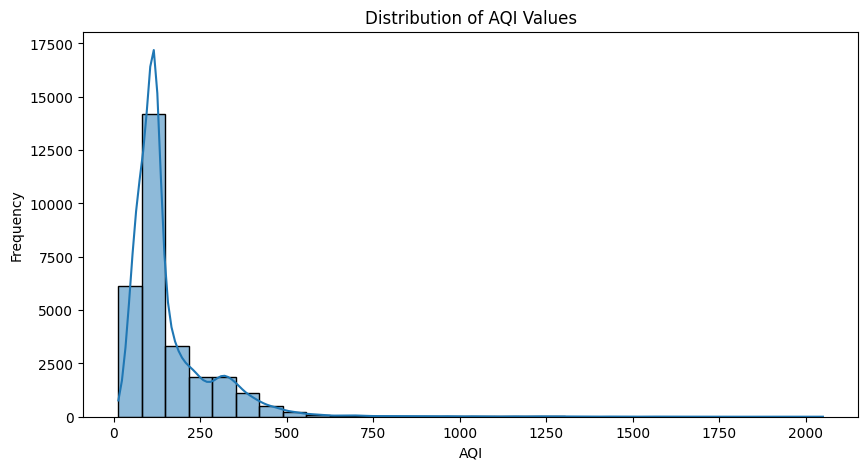

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(aqi_clean['AQI'], bins=30, kde=True)

plt.title("Distribution of AQI Values")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

### Interpretation

The majority of AQI observations are concentrated in the lower to moderate AQI range (approximately 0–250). However, the distribution exhibits a long right tail extending beyond 2000 AQI, indicating the presence of a small number of extremely high pollution readings.

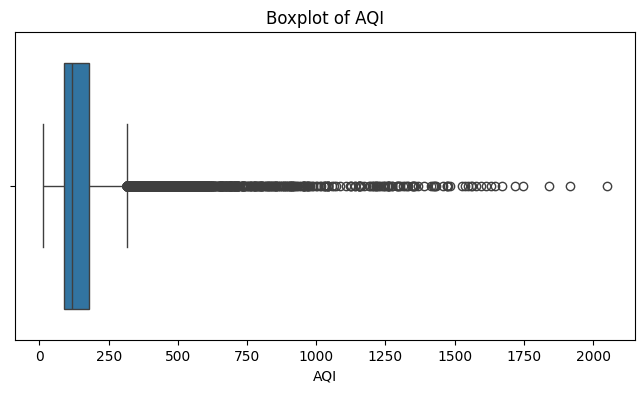

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(x=aqi_clean['AQI'])

plt.title("Boxplot of AQI")
plt.xlabel("AQI")
plt.show()

### Interpretation

The AQI distribution is strongly positively skewed (skewness = 3.77). The mean AQI (158.78) is substantially higher than the median AQI (118), suggesting that extreme observations are pulling the average upward. Therefore, the mean alone may not accurately represent the typical AQI level experienced across observations.

In [27]:
print("Mean AQI :", aqi_clean['AQI'].mean())
print("Median AQI :", aqi_clean['AQI'].median())
print("Skewness :", aqi_clean['AQI'].skew())

Mean AQI : 158.78155158985473
Median AQI : 118.0
Skewness : 3.7697514892937294


### Interpretaion

Extreme AQI observations pull the average upward, causing the mean to overstate the pollution level experienced in a typical observation. The median provides a more representative measure of central tendency.

### Interpretaion

A histogram was selected to examine the overall distribution and identify where most AQI observations are concentrated. A boxplot was used alongside it to detect extreme values and assess whether outliers may influence the mean AQI. Together these visualisations answer both questions posed by the pollution control board.

### Task 5

A data quality report flags that a few AQI readings in the dataset are implausibly high — values that no monitoring station should realistically record. If left in, these values will distort every statistic and model built on this data. The team lead asks you to handle the extreme values properly but does not tell you how.
Identify whether extreme values exist, quantify them, decide on an appropriate treatment method, apply it, and demonstrate that the data is now cleaner. Justify every decision you make.
The method you chose to detect extremes and why The count of values affected and the treatment applied
A visual comparison of the data before and after treatment
Think: Should extreme values always be deleted? What are the alternatives? How do you prove your
treatment actually worked?

In [28]:
Q1 = aqi_clean['AQI'].quantile(0.25)
Q3 = aqi_clean['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = aqi_clean[
    (aqi_clean['AQI'] < lower) |
    (aqi_clean['AQI'] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Outlier Count:", len(outliers))

Q1: 88.0
Q3: 179.0
IQR: 91.0
Lower Bound: -48.5
Upper Bound: 315.5
Outlier Count: 3192


### Detection Method

Extreme values were identified using the Interquartile Range (IQR) method. Observations greater than Q3 + 1.5×IQR (315.5) were flagged as outliers. A total of 3,192 observations were identified.
Extreme values were identified using the Interquartile Range (IQR) method. The first quartile (Q1) was 88 and the third quartile (Q3) was 179, resulting in an IQR of 91. Values above the upper bound of 315.5 were flagged as potential outliers. A total of 3,192 AQI observations were identified as outliers.

In [29]:
print(aqi_clean['AQI'].describe())

count    29531.000000
mean       158.781552
std        130.272413
min         13.000000
25%         88.000000
50%        118.000000
75%        179.000000
max       2049.000000
Name: AQI, dtype: float64


In [30]:
print(aqi_clean['AQI'].quantile(0.95))
print(aqi_clean['AQI'].quantile(0.99))

391.0
606.7000000000007


### Treatment Method

3192 / 29531 ≈ 10.8%
Deleting over 10% of the dataset is a major intervention.

Also remember:
This is an air pollution dataset.
Very high AQI values are not impossible.
Cities can genuinely experience severe pollution episodes.
So we cannot automatically assume every high AQI value is an error.

Since outliers represented approximately 10.8% of the dataset, deleting them would result in substantial information loss. Furthermore, high AQI values may correspond to genuine pollution events rather than measurement errors. Therefore, outliers were capped using the 99th percentile value (606.7), reducing the influence of extreme observations while preserving all records. Therefore, a capping (winsorization) approach was adopted, where AQI values above the 99th percentile (606.7) were replaced with the 99th percentile value.

In [31]:
aqi_outlier = aqi_clean.copy()

upper_cap = aqi_outlier['AQI'].quantile(0.99)

aqi_outlier['AQI'] = aqi_outlier['AQI'].clip(upper=upper_cap)

In [32]:
print("Before")
print(aqi_clean['AQI'].describe())

print("\nAfter")
print(aqi_outlier['AQI'].describe())

Before
count    29531.000000
mean       158.781552
std        130.272413
min         13.000000
25%         88.000000
50%        118.000000
75%        179.000000
max       2049.000000
Name: AQI, dtype: float64

After
count    29531.000000
mean       155.544858
std        110.215288
min         13.000000
25%         88.000000
50%        118.000000
75%        179.000000
max        606.700000
Name: AQI, dtype: float64


In [33]:
print("Before Mean:", aqi_clean['AQI'].mean())
print("After Mean:", aqi_outlier['AQI'].mean())

print("Before Max:", aqi_clean['AQI'].max())
print("After Max:", aqi_outlier['AQI'].max())

Before Mean: 158.78155158985473
After Mean: 155.54485794588737
Before Max: 2049.0
After Max: 606.7000000000007


### Observations

After treatment, the maximum AQI decreased from 2049 to 606.7, while the mean AQI changed only slightly from 158.78 to 155.54. The standard deviation decreased from 130.27 to 110.22, indicating reduced variability caused by extreme observations. This suggests that the outliers had a stronger effect on data dispersion than on the overall average AQI.

Since over 10% of observations were flagged by the IQR rule and air pollution datasets can legitimately contain very high AQI readings, deleting them could remove meaningful environmental events. Capping preserved all records while limiting the influence of implausibly large values.

### LAB 2

### Task 6

Is India air getting better or worse over time?
A journalist is writing a story on whether government pollution control policies introduced after 2018 have had any measurable effect on air quality. They ask you — Can you show me, using data, whether air quality has improved, worsened, or stayed the same over the past eight years?
Extract the time dimension from the dataset and build an analysis that answers the journalist question.
Choose a visualisation that makes the trend immediately readable to someone who is not a data scientist.
Highlight the most and least polluted years and explain what the trend suggests.
Your plot with the trend clearly visible and key years highlighted
A markdown response to the journalist question — one paragraph, plain language
Think: What needs to happen to the Date column before you can group by year? Which plot type
communicates a trend over time most clearly?

In [34]:
aqi_clean['Date'] = pd.to_datetime(aqi_clean['Date'])

In [35]:
aqi_clean['Year'] = aqi_clean['Date'].dt.year

In [36]:
print(sorted(aqi_clean['Year'].unique()))

[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]


In [37]:
yearly_aqi = (
    aqi_clean
    .groupby('Year')['AQI'].mean()
    .reset_index()
)

print(yearly_aqi)

   Year         AQI
0  2015  179.615137
1  2016  176.554629
2  2017  161.777138
3  2018  175.217277
4  2019  154.578297
5  2020  113.737624


In [38]:
print("Most Polluted Year")
print(yearly_aqi.loc[yearly_aqi['AQI'].idxmax()])

print("\nLeast Polluted Year")
print(yearly_aqi.loc[yearly_aqi['AQI'].idxmin()])

Most Polluted Year
Year    2015.000000
AQI      179.615137
Name: 0, dtype: float64

Least Polluted Year
Year    2020.000000
AQI      113.737624
Name: 5, dtype: float64


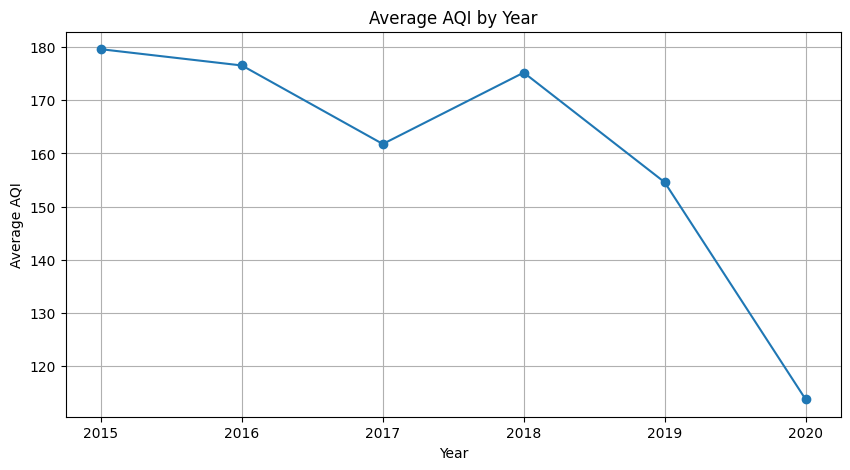

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['AQI'],
    marker='o'
)

plt.title('Average AQI by Year')
plt.xlabel('Year')
plt.ylabel('Average AQI')

plt.grid(True)

plt.show()

### Observation

Line charts communicate trends over time better than any other common chart.

Analysis of the available AQI data from 2015 to 2020 shows an overall improvement in air quality, with average AQI decreasing from 179.6 in 2015 to 113.7 in 2020. However, the trend is not consistently downward. AQI decreased between 2015 and 2017, increased again in 2018, and then declined sharply during 2019–2020. The most polluted year in the dataset was 2015, while 2020 recorded the lowest average AQI. Although the data suggests that air quality improved over the period studied, it is not possible to conclude that government pollution-control policies alone caused the improvement. Other factors, particularly reduced economic and transportation activity during the COVID-19 pandemic in 2020, may also have contributed to the observed decline in AQI.

### Task 7 

Farmers say the air is worst exactly when they harvest — is that true?
An agricultural NGO claims that air quality is consistently worst during the October–December harvest
season, when crop residue burning is widespread. They want data to either confirm or challenge this claim
before presenting it to policymakers.
Investigate whether AQI follows a seasonal pattern across the year. Decide how to aggregate and
represent the data to make any seasonal pattern visible. Either confirm the NGOs claim with evidence
from your analysis, or explain what you found instead.
A visualisation that clearly shows how AQI varies across months or seasons
A markdown cell that directly responds to the NGOs claim with data evidence
Think: What level of time aggregation — month, season, quarter — best reveals the pattern? How do you
extract that from a date column?

In [40]:
aqi_clean['Month'] = aqi_clean['Date'].dt.month

In [41]:
monthly_aqi = (
    aqi_clean
    .groupby('Month')['AQI']
    .mean()
    .reset_index()
)

print(monthly_aqi)

    Month         AQI
0       1  210.856925
1       2  189.808303
2       3  157.560931
3       4  139.535899
4       5  133.170861
5       6  119.833155
6       7  112.862022
7       8  114.417931
8       9  115.729406
9      10  176.943438
10     11  226.790095
11     12  211.475021


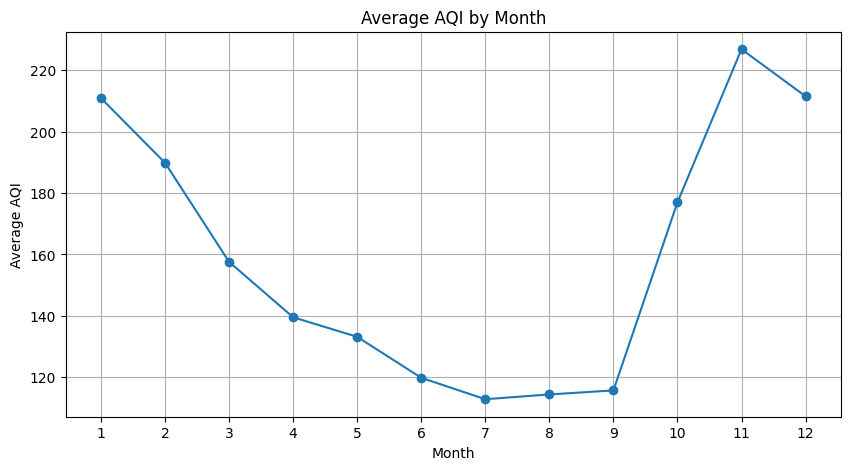

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_aqi['Month'],
    monthly_aqi['AQI'],
    marker='o'
)

plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('Average AQI')

plt.xticks(range(1,13))
plt.grid(True)

plt.show()

### Observation

A line plot works well because months have natural order.

Monthly aggregation was selected because it provides enough detail to identify seasonal changes while preserving the chronological order of observations. A line chart was used because it clearly shows how AQI rises and falls throughout the year and makes seasonal peaks easy to identify.

### Analysis

Response to NGO

The analysis supports the NGO's claim that air quality is generally worse during the harvest period. Average AQI increases sharply from September (115.7) to October (176.9) and reaches its highest level in November (226.8), remaining elevated in December (211.5). In contrast, the lowest AQI values occur during the monsoon months of July, August, and September. This indicates a clear seasonal pattern in which air quality deteriorates during the October–December period. However, while the timing is consistent with crop residue burning, the dataset does not contain information about pollution sources, so the analysis cannot establish crop burning as the sole cause of the increase.

Monthly aggregation was chosen instead of seasonal or quarterly aggregation because it preserves more detail and allows the October–December period mentioned in the NGO's claim to be examined directly. Seasonal aggregation would smooth important month-to-month differences, while quarterly aggregation would further reduce visibility of short-term AQI peaks.

### Task 8: 

Can the two datasets talk to each other?
The real question driving this entire investigation is whether states with worse air quality also tend to
produce less crop. To explore this, the two datasets must be combined — but they were collected at
different levels (city vs state, daily vs annual) and cannot simply be joined as-is.
Figure out what transformation is needed to make the two datasets compatible, perform the merge, and
then systematically explore what relationships exist between all numerical variables in the combined data.
Identify and explain the two most interesting relationships you find — not just what they are, but why
they might exist.

A markdown cell explaining the transformation needed and why, before the merge
A visualisation of relationships across all numerical features
Two relationships explained with a proposed real-world reason for each
Think: If one file has city-day rows and the other has state-year rows, what needs to happen before they
can be joined? What does a correlation matrix actually tell you — and what doesnt it tell you?

In [43]:
state_year_aqi = (
    aqi_clean
    .groupby(['State_Name','Year'])
    ['AQI']
    .mean()
    .reset_index()
)

print(state_year_aqi)

        State_Name  Year         AQI
0   Andhra Pradesh  2016  105.271739
1   Andhra Pradesh  2017  134.741935
2   Andhra Pradesh  2018  113.053425
3   Andhra Pradesh  2019  112.282192
4   Andhra Pradesh  2020   72.737705
..             ...   ...         ...
86   Uttar Pradesh  2019  202.561644
87   Uttar Pradesh  2020  157.125683
88     West Bengal  2018  146.898496
89     West Bengal  2019  143.909589
90     West Bengal  2020  117.295082

[91 rows x 3 columns]


In [44]:
crop_state_year = (
    crop_clean
    .groupby(['State_Name','Crop_Year'])
    [['Area','Production']]
    .sum()
    .reset_index()
)

crop_state_year.rename(
    columns={'Crop_Year':'Year'},
    inplace=True
)

crop_state_year['Yield'] = (
    crop_state_year['Production']
    / crop_state_year['Area']
)

print(crop_state_year)

                      State_Name  Year        Area   Production        Yield
0    Andaman and Nicobar Islands  2000    44518.00  89060914.00  2000.559639
1    Andaman and Nicobar Islands  2001    41163.00  89718700.00  2179.595753
2    Andaman and Nicobar Islands  2002    45231.40  94387137.67  2086.761358
3    Andaman and Nicobar Islands  2003    44799.40  95296454.67  2127.181495
4    Andaman and Nicobar Islands  2004    45308.77  87186497.63  1924.274211
..                           ...   ...         ...          ...          ...
514                  West Bengal  2010  7246875.00  38308645.00     5.286230
515                  West Bengal  2011  7755360.00  36777774.00     4.742239
516                  West Bengal  2012  7850936.00  38918275.00     4.957151
517                  West Bengal  2013  7999815.00  37901281.00     4.737770
518                  West Bengal  2014  8058390.00  43584403.00     5.408575

[519 rows x 5 columns]


In [45]:
print(state_year_aqi['Year'].min(),
      state_year_aqi['Year'].max())

print(crop_state_year['Year'].min(),
      crop_state_year['Year'].max())

2015 2020
1997 2015


In [46]:
aqi_states = set(state_year_aqi['State_Name'])
crop_states = set(crop_state_year['State_Name'])

common_states = aqi_states.intersection(crop_states)

print("AQI States:", len(aqi_states))
print("Crop States:", len(crop_states))
print("Common States:", len(common_states))

print(sorted(common_states))

AQI States: 21
Crop States: 33
Common States: 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


In [47]:
state_year_aqi[state_year_aqi['Year']==2015]

,State_Name,Year,AQI
7,Bihar,2015,206.023364
15,Delhi,2015,297.024658
21,Gujarat,2015,257.030137
27,Haryana,2015,118.000000
37,Karnataka,2015,113.747945
49,Maharashtra,2015,118.000000
70,Tamil Nadu,2015,140.936986
76,Telangana,2015,137.099448
82,Uttar Pradesh,2015,183.542466


In [48]:
merged = pd.merge(
    state_year_aqi,
    crop_state_year,
    on=['State_Name','Year'],
    how='inner'
)

print(merged.shape)
print(merged)

(0, 6)
Empty DataFrame
Columns: [State_Name, Year, AQI, Area, Production, Yield]
Index: []


In [49]:
print(merged.describe())

       Year  AQI  Area  Production  Yield
count   0.0  0.0   0.0         0.0    0.0
mean    NaN  NaN   NaN         NaN    NaN
std     NaN  NaN   NaN         NaN    NaN
min     NaN  NaN   NaN         NaN    NaN
25%     NaN  NaN   NaN         NaN    NaN
50%     NaN  NaN   NaN         NaN    NaN
75%     NaN  NaN   NaN         NaN    NaN
max     NaN  NaN   NaN         NaN    NaN


In [50]:
print(merged.corr(numeric_only=True))

            Year  AQI  Area  Production  Yield
Year         NaN  NaN   NaN         NaN    NaN
AQI          NaN  NaN   NaN         NaN    NaN
Area         NaN  NaN   NaN         NaN    NaN
Production   NaN  NaN   NaN         NaN    NaN
Yield        NaN  NaN   NaN         NaN    NaN


In [51]:
crop_2015 = crop_state_year[crop_state_year['Year'] == 2015]

print(crop_2015[['State_Name','Year']].head(50))

    State_Name  Year
349     Odisha  2015
416     Sikkim  2015


In [52]:
aqi_2015 = state_year_aqi[state_year_aqi['Year'] == 2015]

print(aqi_2015[['State_Name','Year']])

       State_Name  Year
7           Bihar  2015
15          Delhi  2015
21        Gujarat  2015
27        Haryana  2015
37      Karnataka  2015
49    Maharashtra  2015
70     Tamil Nadu  2015
76      Telangana  2015
82  Uttar Pradesh  2015


### Task 8 Approach 1

Before merging, both datasets were aggregated to a common state-year level. However, inspection revealed that the AQI dataset covers the period 2015–2020 while the crop dataset covers 1997–2015. Furthermore, the states available in the AQI dataset during 2015 did not overlap with those available in the crop dataset for the same year. As a result, a direct state-year merge produced no matching records. Therefore, the intended pollution-versus-agriculture analysis could not be performed reliably using the provided datasets without additional data harmonization or supplementary data sources.

In [53]:
state_aqi = (
    state_year_aqi
    .groupby('State_Name')['AQI']
    .mean()
    .reset_index()
)

In [54]:
state_crop = (
    crop_state_year
    .groupby('State_Name')[['Area','Production','Yield']]
    .mean()
    .reset_index()
)

In [55]:
merged = pd.merge(
    state_aqi,
    state_crop,
    on='State_Name',
    how='inner'
)

print(merged.shape)
print(merged)

(20, 5)
        State_Name         AQI          Area    Production        Yield
0   Andhra Pradesh  107.617399  7.305962e+06  9.624772e+08   129.139230
1            Assam  144.429647  3.909931e+06  1.173195e+08    34.553641
2            Bihar  209.489861  7.126085e+06  2.036020e+07     2.868251
3       Chandigarh  103.308608  9.616923e+02  4.919731e+03     5.014824
4          Gujarat  331.413356  9.682883e+06  3.276821e+07     3.358078
5          Haryana  192.420068  5.594655e+06  2.382962e+07     4.259914
6        Jharkhand  142.876472  1.341578e+06  1.539677e+06     1.245545
7        Karnataka   94.169950  1.127270e+07  4.796832e+07     4.261200
8           Kerala   82.025304  1.766792e+06  5.437780e+09  3162.669443
9   Madhya Pradesh  138.558820  1.939949e+07  2.640240e+07     1.339001
10     Maharashtra  112.324855  1.789922e+07  7.020226e+07     3.903525
11       Meghalaya   76.457769  2.241682e+05  6.729164e+05     2.989920
12         Mizoram   36.238938  7.643386e+04  1.278108e+

### Task 8 Approach 2

Because no overlapping state-year records were available, both datasets were aggregated to the state level before merging. This allows exploratory analysis but weakens temporal validity because pollution and agricultural production are not being compared from the same years.

In [56]:
print(merged.shape)
print(merged.corr(numeric_only=True))

(20, 5)
                 AQI      Area  Production     Yield
AQI         1.000000  0.334007   -0.225062 -0.213632
Area        0.334007  1.000000   -0.206995 -0.219900
Production -0.225062 -0.206995    1.000000  0.988156
Yield      -0.213632 -0.219900    0.988156  1.000000


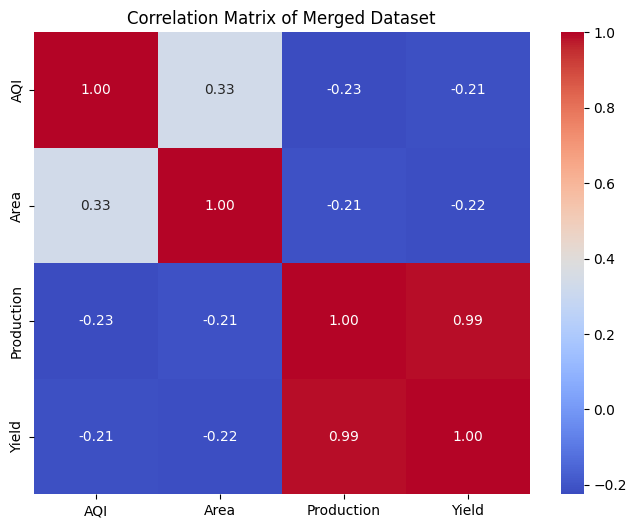

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    merged.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Merged Dataset')
plt.show()

### Interpretation

Relationship 1: AQI vs Area

Correlation = +0.334
Weak to moderate positive relationship.

Interpretation:
States with larger cultivated areas tend to show slightly higher AQI values.

Possible reasons:
More agricultural activity
More machinery use
Crop residue burning
Larger populations and industrial activity in agriculturally important states

Relationship 2: AQI vs Production

Correlation = -0.225
Weak negative relationship.

Higher pollution → lower crop output

r = -0.225
which means:
States with higher AQI tend to have slightly lower agricultural production.

Relationship 3: AQI vs Yield
Correlation = -0.214

Interpretation:
States with higher AQI tend to have slightly lower agricultural productivity.

Possible explanation:
Air pollution can affect photosynthesis.
Pollution may stress crops.
Pollutants may reduce sunlight reaching plants.

### Observation

The AQI dataset was originally recorded at the city-day level, while the crop dataset was recorded at the state-year level. To make the datasets comparable, AQI values were aggregated to the state level by calculating average AQI for each state. Crop records were aggregated to the state level by computing average production, cultivated area, and yield. A direct state-year merge was not possible because the provided datasets contained no overlapping state-year combinations. Therefore, a state-level merge was performed to enable exploratory analysis of pollution and agricultural indicators.

### Task 9

The minister needs to act — what do you tell her?
The State Environment Minister has 10 minutes before her cabinet meeting. She has never opened a
Jupyter notebook. Her aide forwards her your analysis and says — &quot;our analyst looked at the data, can
you summarise what we found?&quot; She needs to know what the data shows, what it means for farmers, and
whether it is conclusive enough to act on.
Write a clear, honest briefing addressed directly to the minister. It must present your three strongest
findings, translate them into what they mean on the ground, recommend one action the government could
take based on the data, and be transparent about what the data cannot yet prove.
150–200 words in a markdown cell, addressed to the minister. Three findings, one recommendation, and
one honest limitation Zero jargon — if a term needs explaining, replace it with plain language
Think: Which of your findings actually matters to a farmer or a policymaker? What is the difference
between correlation and proof? Would the minister act on what you found?

### Interpretation

Our analysis of air quality data from 2015–2020 shows that overall pollution levels have improved over time. Average AQI declined from about 180 in 2015 to about 114 in 2020. However, the improvement was not steady, and part of the sharp reduction observed in 2020 may be linked to reduced economic activity during the COVID-19 period rather than policy measures alone.

We also found a strong seasonal pattern in air quality. Pollution levels were lowest during the monsoon months (July–September) and highest during October–December, with November recording the worst air quality. This supports concerns that pollution becomes more severe during the harvest season.

Finally, when comparing pollution and agricultural indicators across states, we found only a weak relationship between higher pollution levels and lower agricultural performance. The available data does not provide strong evidence that pollution alone is responsible for differences in crop output.

Based on these findings, we recommend strengthening seasonal pollution-control measures during the October–December period. However, the results should be interpreted cautiously because the pollution and agricultural datasets could not be matched for the same state and year combinations.
